# Relatório Final do Trabalho (RFT) - RedVase

- Leonardo Garcia dos Santos
- Ronaldo Avila de Arruda Junior

## 1. Introdução

O objetivo deste trabalho é desenvolver um sistema de inspeção visual de baixo custo para a detecção automática de rachaduras em superfícies rígidas. O software, desenvolvido em Python, analisa o vídeo de uma webcam em tempo real para identificar linhas anômalas que caracterizem trincas. O resultado final entrega uma interface simples onde o sistema processa a imagem da peça de argila e exibe um alerta de "APROVADO" ou "REPROVADO", desenhando um contorno sobre a falha.

### **Cenário de Aplicação (CA)**
O cenário de aplicação foca no controle de qualidade na linha de produção de peças de argila e cerâmica. Durante a fabricação, especificamente após a secagem ou a saída do forno, as peças sofrem choque térmico e frequentemente desenvolvem fissuras e rachaduras maiores.  

Uma entrevista empática com a gerência de qualidade de uma fábrica local confirmou que, atualmente, essa inspeção é realizada de forma 100% manual e a olho nu, com funcionários inspecionando peça por peça sob lâmpadas. O problema dessa abordagem é a fadiga visual, que torna o processo lento e altamente sujeito a falhas humanas, permitindo que produtos rachados cheguem aos clientes e gerem prejuízos com devoluções. Soluções industriais automatizadas, como escâneres 3D e máquinas de raio-x, não são tão práticas e seus custos podem ser acima de R$100.000,00, inviabilizando a adoção por fabricantes. Isso motiva a criação de um sistema de Visão Computacional acessível que opere com câmeras e computadores comuns.

![Alt Text](contextoimg.png)  
*Imagem demonstrativa de vasos de argila com fissuras*

### **Fundamentação Teórica**
A solução técnica baseia-se em conceitos de processamento digital de imagens. A segmentação do objeto é realizada através do espaço de cor HSV. O espaço HSV separa a informação de cor da informação de luz, apresentando robustez a variações de iluminação do ambiente fabril. A extração de características utiliza morfologia matemática. Para encontrar as rachaduras na argila, o sistema aplica o filtro morfológico BlackHat. 
$${\displaystyle T_{b}(f)=f\bullet b-f}$$
Este operador morfológico aplica uma operação de *Fechamento* seguida de subtração pela imagem original, destacando elementos escuros que sejam menores que o kernel de varredura sobre fundos claros, evidenciando fissuras na superfície da peça.

## 2. Materiais e Métodos

### **Diagrama de Blocos Funcional do SPV**
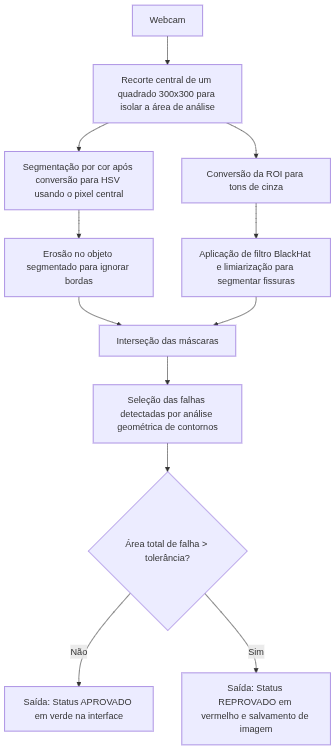

### Descrição da Implementação do SPV
O sistema foi desenvolvido na linguagem **Python**. As operações de visão computacional, captura de vídeo, manipulação de cores, detecção de contornos e renderização da interface gráfica dependem da biblioteca `opencv-python (cv2)`. O cálculo de matrizes de imagem utiliza a biblioteca `numpy`. As bibliotecas nativas `os` e `datetime` atuam no gerenciamento e na criação de pastas e arquivos de log.

O fluxo de processamento foi implementado da seguinte forma:

* **Extração da ROI:** O código recorta uma matriz central de 300x300 pixels do frame da câmera, limitando a área de inspeção.
* **Segmentação de Cor:** A cor da argila é capturada a partir do pixel central da ROI e convertida para o espaço de cor **HSV**, gerando uma máscara que isola a peça do fundo.
* **Isolamento de Bordas:** Uma operação de erosão morfológica é aplicada à máscara do objeto para criar uma margem de segurança nas extremidades.
* **Extração de Fissuras:** O filtro morfológico **BlackHat** atua sobre a ROI em escala de cinza para realçar microfissuras, destacando elementos escuros em fundos claros.
* **Filtragem Geométrica:** Os contornos detectados passam por um filtro que verifica a área mínima, a proporção e a solidez das fissuras detectadas.
* **Interface Interativa:** O software conta com um painel sobreposto que permite ao operador usar o mouse para ajustar os parâmetros de *Sensibilidade do BlackHat* e a *Tolerância da Superfície* clicando nos botões de mais e menos.
* **Saída Visual:** O sistema imprime "APROVADO" (verde) ou "REPROVADO" (vermelho) baseado na área total da falha.



### Análise Técnica

O grau de atendimento do sistema em relação ao contexto escolhido é satisfatório para uma prova de conceito de baixo custo. O software cumpre o objetivo de alertar o operador exibindo o status visual, reduzindo a fadiga operacional e padronizando a inspeção.  

![Alt Text](aprovado.png) ![Alt Text](reprovado.png)  
*Demonstração do sistema detectando corretamente rachaduras em um vaso de argila*  
![Alt Text](Debug.png)  
*Tela de Debug mostrando as etapas intermediárias do sistema*  
A execução em tempo real e a interatividade da calibração foram os pontos de destaque qualitativo do protótipo. O sistema detectou corretamente as rachaduras nas peças de teste.

No entanto, há vulnerabilidades técnicas:

1. A calibração de cor e a detecção sofrem falhas com sombras projetadas, o que gera falsos positivos e resultados inconsistentes.
2. O ajuste excessivo da sensibilidade na interface gera falsos positivos na detecção de rachaduras.

## 3. Laboratório Experimental

### Roteiro do Laboratório Experimental (LEx)
O roteiro de testes práticos seguiu uma progressão de validação funcional e avaliação de usabilidade:
1. Posicionamento da webcam em suporte fixo sobre a área de inspeção.
2. Inicialização do sistema SPV.
3. Exposição dos vasos de argila íntegros e rachados à área de captura (ROI).
4. Variação de posição da peça para confirmar o isolamento de bordas.
5. Testes de estresse da interface, alterando os parâmetros de sensibilidade.
6. Introdução de variações de iluminação e projeção de sombras nas peças inspecionadas.
7. Preenchimento do formulário de avaliação por seis usuários, focando em usabilidade (escala de 1 a 5) e percepção qualitativa.

### Análise dos Resultados Experimentais
Os testes em campo definiram dois critérios principais de avaliação: **eficácia técnica** (detecção correta de rachaduras sem gerar falsos positivos) e **usabilidade** (facilidade de operação por usuários não técnicos).

O questionário mediu a carga cognitiva e o conforto dos usuários no manuseio da ferramenta. Os resultados mostram aprovação da interface:
![Alt Text](Questionario.png)
* A **nota máxima (5)** foi atribuída em todas as avaliações referentes à facilidade de uso, aprendizado rápido e confiança na operação.
* A **nota mínima (1)** foi o padrão para perguntas sobre a complexidade da ferramenta e a necessidade de suporte técnico.
* Apenas uma **leve ressalva** foi feita quanto a inconsistências do sistema (nota 2), relacionada diretamente aos falsos positivos gerados por sombras.

Para complementar a avaliação numérica, as respostas discursivas reforçaram a agilidade da interface, mas também confirmaram as limitações técnicas do protótipo atual. Abaixo, destacam-se as principais percepções registradas pelos testadores:

**O que mais agradou (Agilidade e Precisão):**
> "O resultado em tempo real."  
> "Rápida detecção e fácil de ser testado."  
> "Intuitivo e resolve problema de produção."  
> "Achei ele bem preciso."  

**O que menos agradou (Limitações Técnicas):**
> "A limitação de cores dos vasos. Funciona apenas para vasos de um tipo, mas pode facilmente ser incrementado."  
> "Se aumentar demais a sensibilidade, o sistema falha."  
> "Raramente detecta falhas não consistentes."  


## 4. Conclusões

Os objetivos propostos para o sistema de inspeção visual de baixo custo foram alcançados. O desenvolvimento da prova de conceito comprovou a viabilidade de automatizar a detecção de rachaduras em superfícies rígidas utilizando hardware padrão e a biblioteca OpenCV. O software transfere a carga de decisão da inspeção a olho nu para o processamento digital, mitigando a fadiga visual dos operadores no controle de qualidade.  

A modelagem teórica atendeu parcialmente ao comportamento prático do sistema. A segmentação via espaço de cor HSV isolou a argila, e o filtro BlackHat realçou as microfissuras na superfície conforme especificado. Uma deficiência tecnica é que a lógica aplicada utilizou a erosão morfológica para criar uma margem interna de segurança, ignorando deliberadamente a integridade das bordas do objeto analisado.  

O desempenho da implementação registra resultados positivos na usabilidade, obtendo aceitação irrestrita entre os usuários devido à ausência de barreiras técnicas para a operação. O processamento da imagem e o alerta visual de status ocorrem em tempo real. O uso da filtragem geométrica isola trincas alongadas e descarta alguns dos ruídos comuns inerentes à textura da cerâmica.  

Entretanto, as deficiências da implementação limitam a adoção comercial da versão atual. A pouca tolerância a artefatos provoca instabilidade na análise, convertendo sombras projetadas em peças falsamente reprovadas. A calibração da sensibilidade exige precisão estrita do operador para evitar distorções no limiar de identificação de falhas.  



## 5. Referências Bibliográficas

* [OpenCV: Morphological Transformations](https://docs.opencv.org/3.4/d9/d61/tutorial_py_morphological_ops.html)
* [Filter Color with OpenCV - GeeksforGeeks](https://www.geeksforgeeks.org/python/filter-color-with-opencv/)
* [OpenCV: Getting Started with Videos](https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html)
* [OpenCV: Image Thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)
* Rafael C. Gonzalez. *Digital Image Processing.* 4.ed. Pearson, 2018.



## 6. Anexo

### Código fonte do Sistema

In [ ]:
import cv2
import numpy as np
import os
import datetime

# --- Variáveis Globais de Calibração ---
sensibilidade = 0
tolerancia_px = 40

# Cria o diretório para salvar as falhas
if not os.path.exists('falhas'):
    os.makedirs('falhas')

def controle_mouse(event, x, y, flags, param):
    """
    Detecta cliques do mouse na tela para ajustar os valores.
    Coordenadas (x, y) precisam bater com os retângulos desenhados na interface.
    """
    global sensibilidade, tolerancia_px
    
    if event == cv2.EVENT_LBUTTONDOWN:
        # Linha 1: Sensibilidade (Y entre 20 e 50)
        if 20 <= y <= 50:
            if 300 <= x <= 340: sensibilidade = max(0, sensibilidade - 1)
            elif 360 <= x <= 400: sensibilidade = min(20, sensibilidade + 1)
            
        # Linha 2: Tolerância Superfície (Y entre 60 e 90)
        elif 60 <= y <= 90:
            if 300 <= x <= 340: tolerancia_px = max(0, tolerancia_px - 5)
            elif 360 <= x <= 400: tolerancia_px = min(300, tolerancia_px + 5)

def desenhar_painel_sobreposto(frame):
    """
    Desenha o painel de controle escuro com botões sobre a imagem da câmera.
    """
    cv2.rectangle(frame, (10, 10), (420, 105), (30, 30, 30), -1)
    cv2.rectangle(frame, (10, 10), (420, 105), (200, 200, 200), 1) 

    linhas = [
        (f"Sensib. BlackHat: {sensibilidade}", 40, 20),
        (f"Tol. Superficie (px): {tolerancia_px}", 80, 60)
    ]

    for texto, y_texto, y_botao in linhas:
        cv2.putText(frame, texto, (20, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.rectangle(frame, (300, y_botao), (340, y_botao + 30), (0, 0, 180), -1)
        cv2.putText(frame, "-", (312, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        cv2.rectangle(frame, (360, y_botao), (400, y_botao + 30), (0, 180, 0), -1)
        cv2.putText(frame, "+", (372, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        
    return frame

def segmentar_cor_central(img_bgr):
    """
    Pega a cor exata do pixel central do ROI e cria uma máscara baseada nela.
    """
    # Suaviza para evitar que um único pixel de ruído bagunce a leitura
    img_suavizada = cv2.GaussianBlur(img_bgr, (5, 5), 0)
    hsv = cv2.cvtColor(img_suavizada, cv2.COLOR_BGR2HSV)
    
    altura, largura = hsv.shape[:2]
    cy, cx = altura // 2, largura // 2
    
    # Pega o valor HSV do pixel central
    pixel_central_hsv = hsv[cy, cx]
    
    # Se o pixel central for muito escuro ou muito desbotado, ignora (fundo vazio)
    if pixel_central_hsv[1] < 40 or pixel_central_hsv[2] < 40:
         return np.zeros(hsv.shape[:2], dtype=np.uint8)
         
    cor_alvo_hue = int(pixel_central_hsv[0])
    hue_tol = 15 # Tolerância do matiz
    
    # Calcula os limites com proteção para a virada do ciclo de cores (180 graus)
    lower_hue = cor_alvo_hue - hue_tol
    upper_hue = cor_alvo_hue + hue_tol
    
    if lower_hue < 0:
        mask1 = cv2.inRange(hsv, np.array([180 + lower_hue, 40, 40]), np.array([180, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([0, 40, 40]), np.array([upper_hue, 255, 255]))
        mask = cv2.bitwise_or(mask1, mask2)
    elif upper_hue > 180:
        mask1 = cv2.inRange(hsv, np.array([lower_hue, 40, 40]), np.array([180, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([0, 40, 40]), np.array([upper_hue - 180, 255, 255]))
        mask = cv2.bitwise_or(mask1, mask2)
    else:
        mask = cv2.inRange(hsv, np.array([lower_hue, 40, 40]), np.array([upper_hue, 255, 255]))
        
    # desenha um pontinho no centro da imagem_bgr para ver onde ele está lendo a cor
    cv2.circle(img_bgr, (cx, cy), 3, (0, 255, 0), -1)
    
    return mask

def analisar_roi_robusto(imagem_roi, sensibilidade_ajuste, tol_pixels):
    img_resultado = imagem_roi.copy()
    
    # Segmentação base
    mascara_cor = segmentar_cor_central(imagem_roi)
    
    kernel_limpeza = np.ones((7, 7), np.uint8)
    mascara_objeto = cv2.morphologyEx(mascara_cor, cv2.MORPH_OPEN, kernel_limpeza)
    mascara_objeto = cv2.morphologyEx(mascara_objeto, cv2.MORPH_CLOSE, kernel_limpeza)
    
    
    # Erosão para criar uma margem de segurança nas bordas
    # Quanto maior o kernel (ex: 15, 15), mais distante da borda ele ignora as falhas.
    kernel_margem = np.ones((15, 15), np.uint8)
    mascara_analise = cv2.erode(mascara_objeto, kernel_margem, iterations=1)
    
    # Filtro BlackHat
    cinza = cv2.cvtColor(imagem_roi, cv2.COLOR_BGR2GRAY)
    kernel_blackhat = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    blackhat = cv2.morphologyEx(cinza, cv2.MORPH_BLACKHAT, kernel_blackhat)
    
    limiar_base = max(5, min(25 - sensibilidade_ajuste, 255))
    _, trincas_binarias = cv2.threshold(blackhat, limiar_base, 255, cv2.THRESH_BINARY)
    
    # Cruza o blackhat com a máscara
    trincas_no_objeto = cv2.bitwise_and(trincas_binarias, mascara_analise)
    contornos_trincas, _ = cv2.findContours(trincas_no_objeto, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mascara_trincas_finais = np.zeros_like(trincas_no_objeto)
    
    for cnt in contornos_trincas:
        area_contorno = cv2.contourArea(cnt)
        if area_contorno > 10: 
            rect = cv2.minAreaRect(cnt)
            largura, altura = rect[1]
            if largura > 0 and altura > 0:
                proporcao = max(largura, altura) / min(largura, altura)
                hull = cv2.convexHull(cnt)
                hull_area = cv2.contourArea(hull)
                solidity = area_contorno / hull_area if hull_area > 0 else 0
                
                if proporcao > 1.5 and solidity < 0.9:
                    cv2.drawContours(mascara_trincas_finais, [cnt], -1, 255, thickness=cv2.FILLED)

    area_falha_px = cv2.countNonZero(mascara_trincas_finais)
    aprovado_geral = (area_falha_px <= tol_pixels)

    img_resultado[mascara_trincas_finais == 255] = [0, 255, 255] 
    
    imagens_debug = {
        "1. Mascara Cor (Centro)": mascara_cor,
        "2. Mascara Analise (Com Margem)": mascara_analise, # Atualizado no debug para você ver a margem
        "3. Filtro BlackHat": blackhat,
        "4. Trincas Finais": mascara_trincas_finais
    }
    
    return img_resultado, aprovado_geral, imagens_debug

def mostrar_painel_debug(imagens_debug):
    nomes = list(imagens_debug.keys())
    imgs_bgr = [cv2.cvtColor(img, cv2.COLOR_GRAY2BGR) if len(img.shape) == 2 else img for img in imagens_debug.values()]
    for i in range(4): cv2.putText(imgs_bgr[i], nomes[i], (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    painel = np.vstack((np.hstack((imgs_bgr[0], imgs_bgr[1])), np.hstack((imgs_bgr[2], imgs_bgr[3]))))
    cv2.imshow("Painel de Debug CV", cv2.resize(painel, (600, 600)))

def main():
    global sensibilidade, tolerancia_px
    
    cap = cv2.VideoCapture(0)
    falha_ja_salva = False 
    
    cv2.namedWindow("Inspecao de Qualidade")
    cv2.setMouseCallback("Inspecao de Qualidade", controle_mouse)
    
    largura_roi = 300
    altura_roi = 300
    
    while True:
        ret, frame = cap.read()
        if not ret: break
            
        altura_tela, largura_tela = frame.shape[:2]
        x1, y1 = (largura_tela - largura_roi) // 2, (altura_tela - altura_roi) // 2
        x2, y2 = x1 + largura_roi, y1 + altura_roi
        
        roi_vivo = frame[y1:y2, x1:x2]
        frame_exibicao = frame.copy()
        
        roi_processado, aprovado, ultimo_debug = analisar_roi_robusto(
            roi_vivo, sensibilidade, tolerancia_px
        )
        
        # Desenha uma pequena mira em cruz no centro do ROI na tela principal para guiar o usuário
        centro_x_tela = x1 + (largura_roi // 2)
        centro_y_tela = y1 + (altura_roi // 2)
        cv2.drawMarker(frame_exibicao, (centro_x_tela, centro_y_tela), (0, 255, 0), markerType=cv2.MARKER_CROSS, markerSize=20, thickness=2)
        
        frame_exibicao[y1:y2, x1:x2] = roi_processado
        
        cor = (0, 255, 0) if aprovado else (0, 0, 255)
        texto = "APROVADO" if aprovado else "REPROVADO"
        
        cv2.rectangle(frame_exibicao, (x1, y1), (x2, y2), cor, 3)
        cv2.putText(frame_exibicao, texto, (50, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.5, cor, 4)
        
        mostrar_painel_debug(ultimo_debug)
        
        if not aprovado:
            if not falha_ja_salva:
                data_hora = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
                nome_arquivo = f"falhas/reprovado_{data_hora}.jpg"
                cv2.imwrite(nome_arquivo, frame_exibicao)
                falha_ja_salva = True 
        else:
            falha_ja_salva = False
            
        frame_final = desenhar_painel_sobreposto(frame_exibicao)
        cv2.imshow("Inspecao de Qualidade", frame_final)
            
        tecla = cv2.waitKey(1) & 0xFF
        if tecla == 27: 
            break
                
    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()